## Task 1: Import Libraries and Modules

In [9]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

## Task 2: Load the Dataset

In [10]:
df = pd.read_csv('./datafile.csv')
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


## Task 3: Remove Duplicate Values

In [11]:
print("Duplicate Values: ", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.head()

Duplicate Values:  17


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


## Task 4: Create a Histogram of Traffic Volume

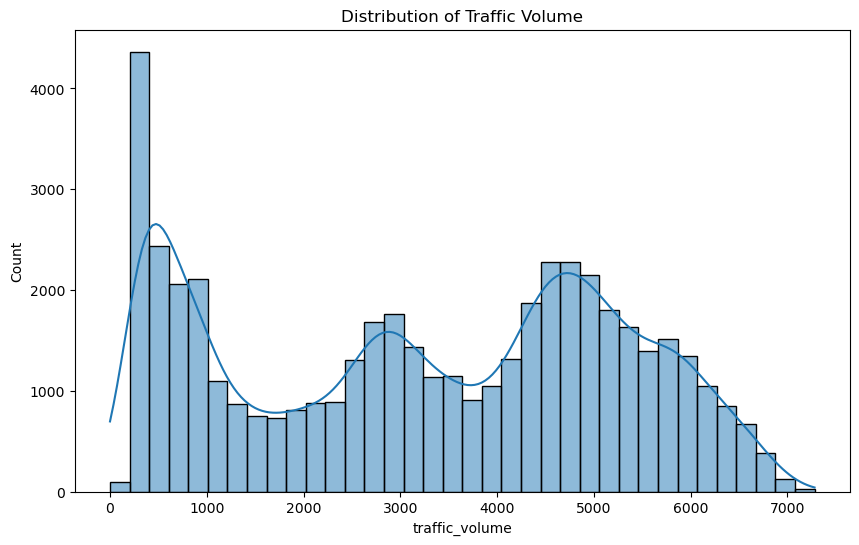

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['traffic_volume'], kde=True)
plt.title('Distribution of Traffic Volume')
plt.show()

## Task 5: Get the Date and Time

In [14]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
df['day'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['hour'] = df['date_time'].dt.hour
df.drop('date_time', axis=1, inplace=True)
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,day,month,year,hour
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,Tuesday,10,2012,9
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,Tuesday,10,2012,10
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,Tuesday,10,2012,11
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,Tuesday,10,2012,12
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,Tuesday,10,2012,13


## Task 6: Convert Categorical Columns to Numerical

In [15]:
df = pd.get_dummies(df, columns=list(set(df.columns) - set(df._get_numeric_data().columns)))

## Task 7: Create Input and Output Parameters

In [16]:
x = df.drop('traffic_volume', axis = 1)
y = df['traffic_volume']

## Task 8: Split the Training and Testing Data

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.85, shuffle=True, random_state=42)

## Task 9: Build the Models

In [18]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor()
}

## Task 10: Train the Models

In [19]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(x_train, y_train)

Training Linear Regression...
Training Decision Tree...
Training Random Forest...


## Task 11: Evaluate the Models

In [20]:
model_list = []
train_r2_score = []
test_r2_score = []
train_mean_squared_error = []
test_mean_squared_error = []

for name, model in models.items():
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)

    model_list.append(name)
    train_r2_score.append(r2_score(y_train,pred_train))
    test_r2_score.append(r2_score(y_test,pred_test))
    train_mean_squared_error.append(mean_squared_error(y_train,pred_train))
    test_mean_squared_error.append(mean_squared_error(y_test,pred_test))

In [21]:
# Fit them all into a dict variable so easy for converting into DataFrame
data_frame = {}
data_frame['model'] = model_list
data_frame['train_r2_score'] = train_r2_score
data_frame['test_r2_score'] = test_r2_score
data_frame['train_mean_squared_error'] = train_mean_squared_error
data_frame['test_mean_squared_error'] = test_mean_squared_error

data_frame = pd.DataFrame(data_frame)

In [22]:
data_frame

,model,train_r2_score,test_r2_score,train_mean_squared_error,test_mean_squared_error
0,Linear Regression,0.201205,-4.008000,3.147694e+06,1.997650e+07
1,Decision Tree,0.999996,0.928720,1.593960e+01,2.843289e+05
2,Random Forest,0.993370,0.959126,2.612739e+04,1.630445e+05


<Axes: xlabel='test_r2_score', ylabel='model'>

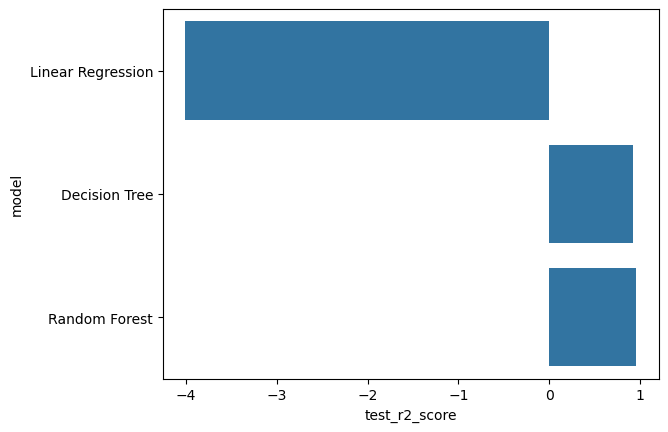

In [23]:
# passing the EXACT Column name to "x" or "y" as it is named in the DataFrame -> it will identify the column from it
sns.barplot(y='model',x='test_r2_score',data=data_frame,orient='h')

## Task 12: Save the Models

In [26]:
import os
for model_name, model in models.items():
    file_path = os.path.join("./", f"{model_name}.pkl")
    joblib.dump(model, file_path)
    print(f"{model_name} model saved to {file_path}")

Linear Regression model saved to ./Linear Regression.pkl
Decision Tree model saved to ./Decision Tree.pkl
Random Forest model saved to ./Random Forest.pkl


## Task 13: Load and Use the Models

In [28]:
loaded_models = []

for i in range(3):
    loaded_models.append(joblib.load("./" + model_list[i] + ".pkl"))
    print(f"Model {model_list[i]} loaded successfully.")

Model Linear Regression loaded successfully.
Model Decision Tree loaded successfully.
Model Random Forest loaded successfully.


In [29]:
# iloc: "integer location" -> It tells pandas that you want to select data using integer-based indexing (row and column numbers)
sample_data = x_test.iloc[:10]
y_test = y_test.iloc[:10]

In [30]:
model_list

['Linear Regression', 'Decision Tree', 'Random Forest']

In [31]:
loaded_models

[LinearRegression(), DecisionTreeRegressor(), RandomForestRegressor()]

In [32]:
# pair up the model name with the model 
# NOTE: The order in of element both list must correspond
named_loaded_models = zip(model_list, loaded_models)

In [33]:
for name, model in named_loaded_models:
    print(f"{name}: {model}")

Linear Regression: LinearRegression()
Decision Tree: DecisionTreeRegressor()
Random Forest: RandomForestRegressor()


In [34]:
for name, model in named_loaded_models:
    prediction = model.predict(sample_data)
    mse = mean_squared_error(y_test, prediction)
    print(f"{model_name} MSE: {mse}")